In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import importlib

if 'oscillator_model' not in os.listdir(): 
    os.chdir('..')

import oscillator_model.oscillator
importlib.reload(oscillator_model.oscillator)
from oscillator_model.oscillator import Oscillator

import oscillator_model.utils
importlib.reload(oscillator_model.utils)
from oscillator_model.utils import *

Text(0.5, 0, 'f (Hz)')

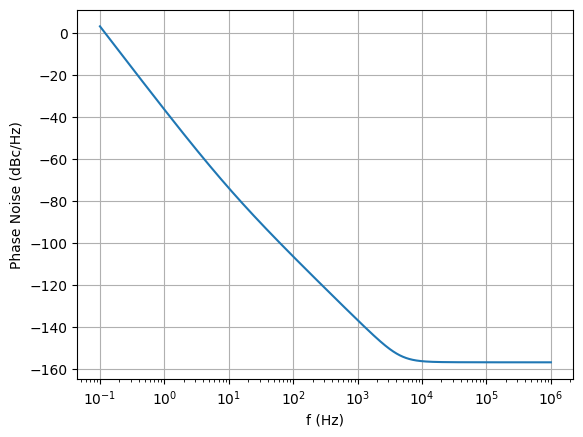

In [3]:
fosc = 10e6
fc = 1e9
fs = 200.0
T = 100.0 
n_periods = 10
n_captures = 1
start_period = 5
example_coeffs_dB = {"a0": -160, "a1": -135, "a2": -190, "a3": -50, "a4": -40}

osc = Oscillator(
    fosc=fosc, 
    fc=fc, 
    fs=fs, 
    T=T,
    n_periods=n_periods, 
    n_captures=n_captures, 
    start_period=start_period, 
    coeffs_dB=example_coeffs_dB
)




fgrid = np.logspace(-1, 6, 2000)
fgrid, S1_vals_linear = osc.S1(fgrid)
S1_vals_dB = lin_to_db(S1_vals_linear)

plt.semilogx(fgrid, S1_vals_dB)
plt.grid()
plt.ylabel('Phase Noise (dBc/Hz)')
plt.xlabel('f (Hz)')

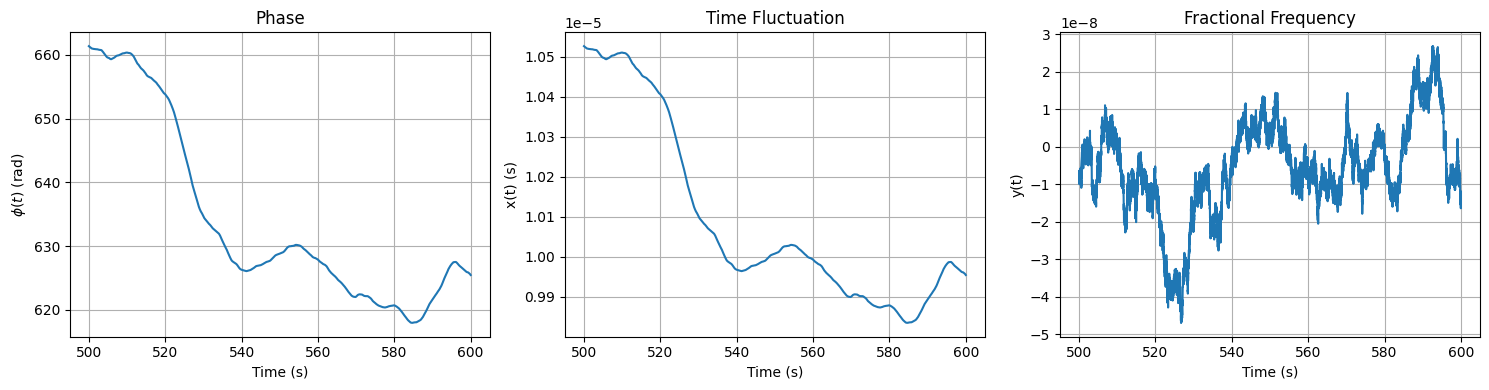

In [4]:
osc.realize_phase_error()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(osc.t_out, osc.phi_out)
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel(r'$\phi(t)$ (rad)')
axs[0].set_title('Phase')
axs[0].grid()

x_t = osc.time_fluctuation(osc.phi_out)
axs[1].plot(osc.t_out, x_t)
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('x(t) (s)')
axs[1].set_title('Time Fluctuation')
axs[1].grid(True)

y_t = osc.fractional_frequency(osc.phi_out)
axs[2].plot(osc.t_out[1:], y_t)
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('y(t)')
axs[2].set_title('Fractional Frequency')
axs[2].grid()

plt.tight_layout()

In [5]:
osc.realize_phase_error()
result = osc.variance_check()
print(f"Expected variance (PSD integral): {result['expected']:.4e}")
print(f"Realized variance: {result['realized']:.4e}")
print(f"Relative error: {result['rel_error_pct']:.4f} %")

Expected variance (PSD integral): 2.1649e+05
Realized variance: 2.1649e+05
Relative error: 0.0000 %


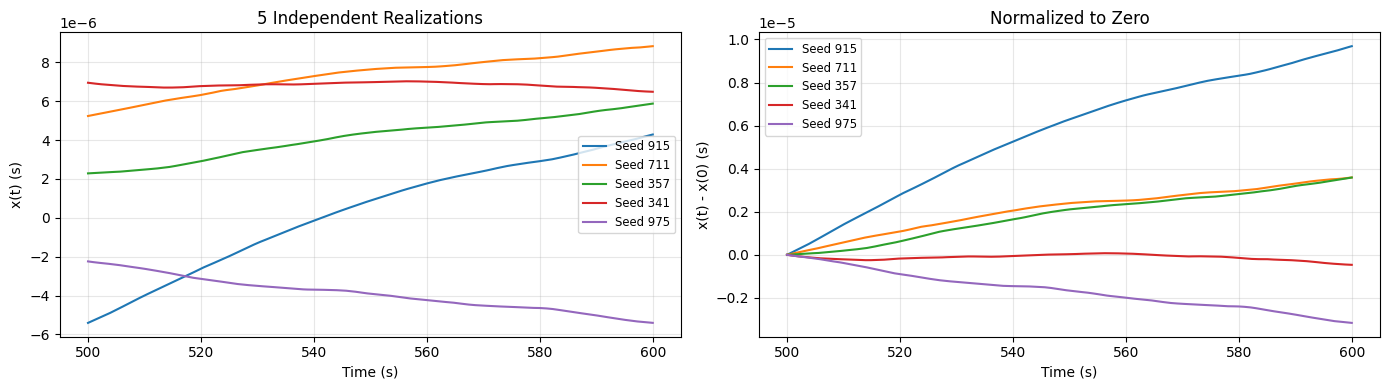

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for i in range(5):
    seed = np.random.randint(1, 1000)
    osc.update_seed(seed)
    osc.realize_phase_error()
    x_t = osc.time_fluctuation(osc.phi_out)
    
    axs[0].plot(osc.t_out, x_t, label=f'Seed {seed}')
    axs[1].plot(osc.t_out, x_t - x_t[0], label=f'Seed {seed}')

axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('x(t) (s)')
axs[0].set_title('5 Independent Realizations')
axs[0].legend(fontsize='small')
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('x(t) - x(0) (s)')
axs[1].set_title('Normalized to Zero')
axs[1].legend(fontsize='small')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()

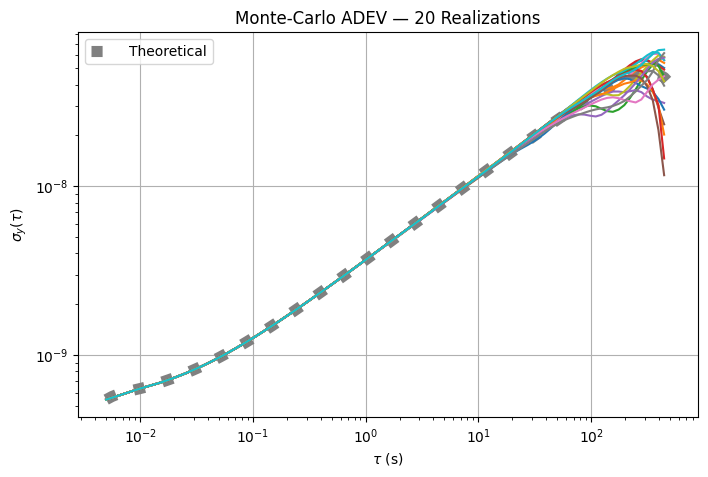

In [7]:
plt.figure(figsize=(8, 5))
for i in range(20):
    seed = np.random.randint(1, 1000)
    osc.update_seed(seed)
    osc.realize_phase_error()
    taus, sigma_ys = osc.allan_dev_from_phase_realization(phi_type='lo')
    plt.loglog(taus, sigma_ys, zorder=i+30)

taus_ref, adev_ref = osc.allan_dev_from_phase_psd()
plt.loglog(taus_ref, adev_ref, ':', lw=8, label='Theoretical', color='gray')
plt.xlabel(r'$\tau$ (s)')
plt.ylabel(r'$\sigma_y(\tau)$')
plt.title('Monte-Carlo ADEV — 20 Realizations')
plt.legend()
plt.grid()